In [ ]:
#1. Import Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")

In [3]:
#2. Load Dataset
df = pd.read_csv("raw_data.csv", encoding='latin-1', header=None)

# Select only needed columns
df = df[[0, 5]]
df.columns = ["sentiment", "text"]

df.head()

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [4]:
#3. Basic Info
df.shape

(1600000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1600000 non-null  int64 
 1   text       1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB


In [6]:
df.describe()

,sentiment
count,1.600000e+06
mean,2.000000e+00
std,2.000001e+00
min,0.000000e+00
25%,0.000000e+00
50%,2.000000e+00
75%,4.000000e+00
max,4.000000e+00


In [7]:
df.isnull().sum()

sentiment    0
text         0
dtype: int64

In [8]:
#4. Convert Target Variable
# 0 = negative, 4 = positive → convert to 0 / 1
df["sentiment"] = df["sentiment"].replace(4, 1)

In [9]:
#5. Duplicate Removal 
df.duplicated().sum()

np.int64(16309)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
#6. Missing Values Check
df.isnull().sum()

sentiment    0
text         0
dtype: int64

In [13]:
#7. Text Cleaning 
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"@\w+", "", text)  # remove mentions
    text = re.sub(r"#\w+", "", text)  # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)  # remove special chars
    text = text.strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df.head()

,sentiment,text,clean_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david car...
1,0,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,0,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


In [14]:
#8. Text Length Feature
df["text_length"] = df["clean_text"].apply(len)

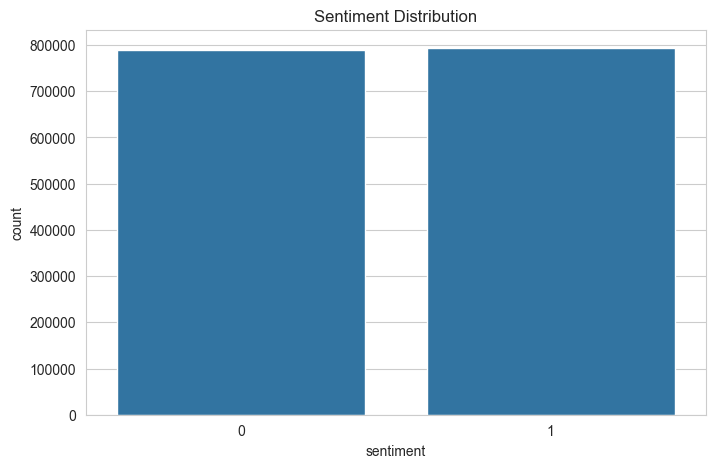

In [15]:
#9. EDA 
#9.1 Sentiment Count
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

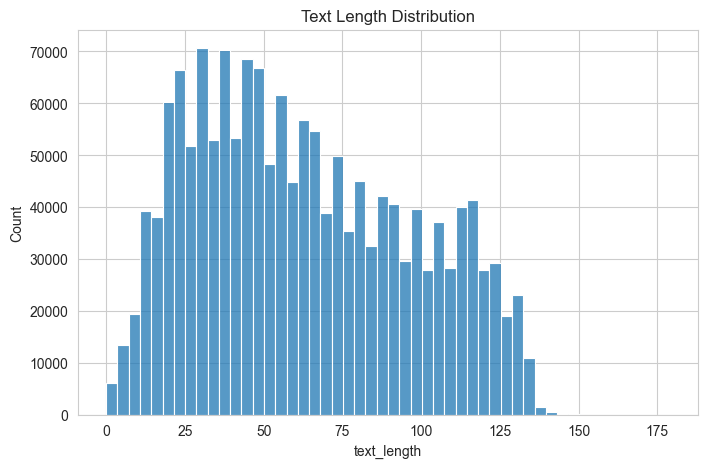

In [16]:
#9.2 Text Length Distribution
sns.histplot(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

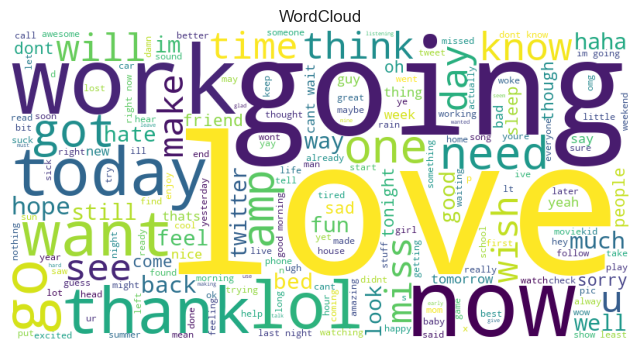

In [17]:
#9.3 WordCloud 
text_all = " ".join(df["clean_text"])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud")
plt.show()

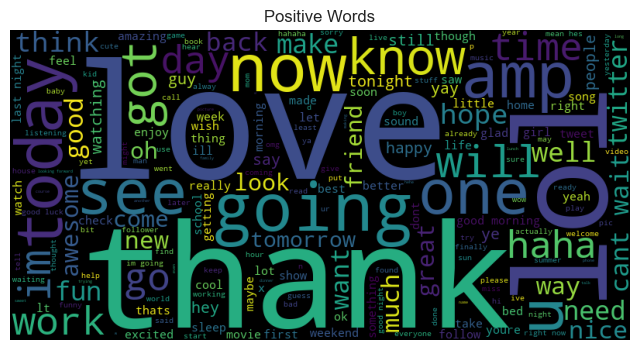

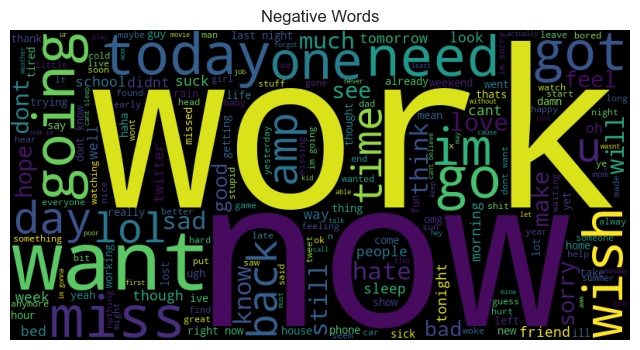

In [18]:
#9.4 Positive vs Negative WordCloud
pos_text = " ".join(df[df["sentiment"]==1]["clean_text"])
neg_text = " ".join(df[df["sentiment"]==0]["clean_text"])

wc_pos = WordCloud(width=800, height=400).generate(pos_text)
wc_neg = WordCloud(width=800, height=400).generate(neg_text)

plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Words")
plt.show()

plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Words")
plt.show()

In [19]:
#10. TF-IDF Vectorization 
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_text"])
y = df["sentiment"]

In [20]:
#11. Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
#12. Model Training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
#13. Evaluation 
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7901079437644244
              precision    recall  f1-score   support

           0       0.80      0.77      0.79    157956
           1       0.78      0.81      0.79    158783

    accuracy                           0.79    316739
   macro avg       0.79      0.79      0.79    316739
weighted avg       0.79      0.79      0.79    316739



In [23]:
#14. Save Cleaned Data
df.to_csv("cleaned_data.csv", index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1583691 entries, 0 to 1599999
Data columns (total 4 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   sentiment    1583691 non-null  int64 
 1   text         1583691 non-null  object
 2   clean_text   1583691 non-null  object
 3   text_length  1583691 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 60.4+ MB


In [25]:
df.columns

Index(['sentiment', 'text', 'clean_text', 'text_length'], dtype='object')